In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split


In [ ]:
df = pd.read_csv('train.csv')
##filter out cats
df = df[df['Type'] == 1]
##filter quantity to 1
df = df[df['Quantity'] == 1]
##Drop na
df = df.dropna()
##Drop columns
X = df.drop(columns=['RescuerID', 'Description','PetID','Name','AdoptionSpeed'])
y = df['AdoptionSpeed']

##encode categorical data
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_encoded = pd.DataFrame(encoder.fit_transform(X[['Type', 'Breed1', 'Breed2', 'Gender', 'Color1', 'Color2', 'Color3', 'MaturitySize', 'FurLength', 'Vaccinated', 'Dewormed', 'Sterilized', 'Health', 'State']]), columns=encoder.get_feature_names_out(['Type', 'Breed1', 'Breed2', 'Gender', 'Color1', 'Color2', 'Color3', 'MaturitySize', 'FurLength', 'Vaccinated', 'Dewormed', 'Sterilized', 'Health', 'State']))

##concatenate encoded data with numerical data
X_numeric = X.select_dtypes(include=['int64', 'float64']).reset_index(drop=True)
X_encoded = X_encoded.reset_index(drop=True)
X_transformed = pd.concat([X_numeric, X_encoded], axis=1)

##split into train test sets
X_train, X_test, y_train, y_test = train_test_split(X_transformed, y, test_size=0.25)

,Type,Age,Breed1,Breed2,Gender,Color1,Color2,Color3,MaturitySize,FurLength,...,State_41330,State_41332,State_41335,State_41336,State_41342,State_41345,State_41361,State_41367,State_41401,State_41415
0,1,1,307,0,1,2,7,0,2,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1,4,307,0,2,1,2,0,2,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,1,1,307,0,1,1,0,0,2,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1,0,307,0,2,1,2,7,2,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1,2,307,0,1,1,2,7,2,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [ ]:
df = pd.read_csv('train.csv')
##filter out cats
df = df[df['Type'] == 1]
##filter quantity to 1
df = df[df['Quantity'] == 1]
##Drop na
df = df.dropna()
##Drop columns
X = df.drop(columns=['RescuerID', 'Description','PetID','Name','AdoptionSpeed', 'Type', 'Quantity'])
y = df['AdoptionSpeed']
X_numeric = df.drop(columns=['RescuerID', 'Description','PetID','Name','AdoptionSpeed', 'Breed1', 'Breed2', 'Gender', 'Color1', 'Color2', 'Color3', 'MaturitySize', 'FurLength', 'Vaccinated', 'Dewormed', 'Sterilized', 'Health', 'State', 'Type', 'Quantity'])
X_categorical = df[['Breed1', 'Breed2', 'Gender', 'Color1', 'Color2', 'Color3', 'MaturitySize', 'FurLength', 'Vaccinated', 'Dewormed', 'Sterilized', 'Health', 'State']]

##sample size, mean and std and 5 number summary for numeric variable
print(X_numeric.describe())

##Samples size and category counts for categorical variables
for col in X_categorical.columns:
    print(X_categorical[col].value_counts())


               Age          Fee     VideoAmt     PhotoAmt
count  6238.000000  6238.000000  6238.000000  6238.000000
mean     14.503687    27.519397     0.052100     3.490702
std      22.571403    90.737462     0.313776     3.095688
min       0.000000     0.000000     0.000000     0.000000
25%       2.000000     0.000000     0.000000     1.000000
50%       4.000000     0.000000     0.000000     3.000000
75%      17.000000     0.000000     0.000000     5.000000
max     255.000000  2000.000000     6.000000    30.000000
Breed1
307    4343
141     167
205     164
179     153
218     138
       ... 
93        1
25        1
154       1
192       1
81        1
Name: count, Length: 108, dtype: int64
Breed2
0      4332
307    1270
218      79
141      57
103      47
       ... 
25        1
111       1
4         1
36        1
5         1
Name: count, Length: 78, dtype: int64
Gender
2    3607
1    2631
Name: count, dtype: int64
Color1
1    2788
2    2137
5     498
7     312
3     294
4     129
6  

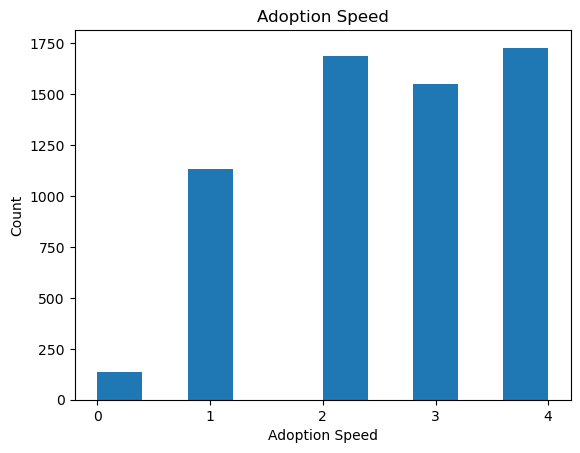

Text(0, 0.5, 'Age')

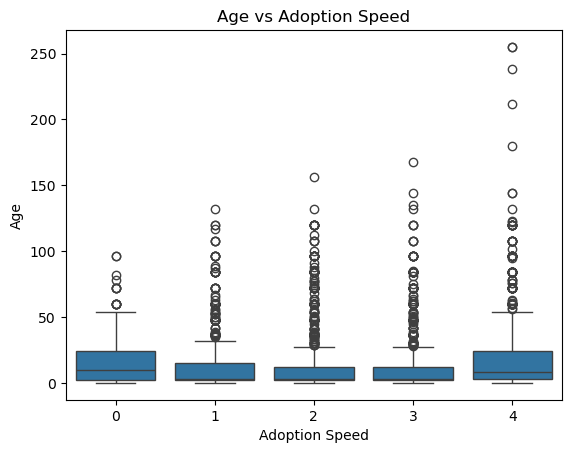

In [ ]:
##Visualizaitons
import matplotlib.pyplot as plt
import seaborn
##histogram of adoption speed
##either 0,1,2,3, or 4
plt.hist(y)
plt.title('Adoption Speed')
plt.xlabel('Adoption Speed')
plt.ylabel('Count')
##adjust bins to only show 0,1,2,3,4
plt.xticks([0,1,2,3,4])
plt.show()
plt.clf()

##boxplot of age and adoptions speed
seaborn.boxplot(x='AdoptionSpeed', y='Age', data=df)
plt.title('Age vs Adoption Speed')
plt.xlabel('Adoption Speed')
plt.ylabel('Age in months')
